# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [43]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Library berhasil di-import')

Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [44]:
# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
df_whr = pd.read_excel('WHR26_Data_Figure_2.1.xlsx')

print(f'Shape dataset: {df_whr.shape}')

Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [45]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [46]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [47]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [48]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing' : df_whr.isnull().sum(),
    'Persentase (%)'  : (df_whr.isnull().sum() / len(df_whr) * 100).round(2)
})
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Explained by: Log GDP per capita,1097,51.84
Explained by: Social support,1097,51.84
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94
Explained by: Generosity,1097,51.84
Explained by: Perceptions of corruption,1098,51.89
Dystopia + residual,1103,52.13


**f.** Buat DataFrame `df_idn` — data Indonesia tahun 2016–2026.

In [158]:
# f. Filter data Indonesia 2006–2023
df_idn = df_whr[
    (df_whr['Country name'] == 'Indonesia') &
    (df_whr['Year'].between(2021, 2025))
].reset_index(drop=True)

print(f'Jumlah baris df_idn: {len(df_idn)}')
display(df_idn)

Jumlah baris df_idn: 5


,Year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,87,Indonesia,5.617,5.517,5.718,1.512,1.229,0.485,1.043,0.295,0.033,1.020
1,2024,83,Indonesia,5.617,5.516,5.717,1.288,1.372,0.454,0.918,0.323,0.044,1.218
2,2023,80,Indonesia,5.568,5.466,5.670,1.361,1.184,0.472,0.779,0.399,0.055,1.318
3,2022,84,Indonesia,5.277,5.161,5.392,1.384,1.169,0.314,0.663,0.422,0.038,1.288
4,2021,87,Indonesia,5.240,5.139,5.341,1.382,0.883,0.539,0.620,0.468,0.047,1.300


In [159]:
df = df_idn.rename(columns={
    'Explained by: Log GDP per capita': 'Log GDP per capita',
    'Explained by: Social support': 'Social support',
    'Explained by: Healthy life expectancy': 'Healthy life expectancy',
    'Explained by: Generosity': 'Generosity',
    'Explained by: Perceptions of corruption': 'Perceptions of corruption',
    "Explained by: Freedom to make life choices":" Freedom to make life choices"
}).copy()

display(df.head())

,Year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,2025,87,Indonesia,5.617,5.517,5.718,1.512,1.229,0.485,1.043,0.295,0.033,1.020
1,2024,83,Indonesia,5.617,5.516,5.717,1.288,1.372,0.454,0.918,0.323,0.044,1.218
2,2023,80,Indonesia,5.568,5.466,5.670,1.361,1.184,0.472,0.779,0.399,0.055,1.318
3,2022,84,Indonesia,5.277,5.161,5.392,1.384,1.169,0.314,0.663,0.422,0.038,1.288
4,2021,87,Indonesia,5.240,5.139,5.341,1.382,0.883,0.539,0.620,0.468,0.047,1.300


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ *Jawaban Anda di sini:*

- **Kualitatif** :  
  - Nominal  :  
  - Ordinal  :  
- **Kuantitatif** :  
  - Diskrit  :  
  - Kontinu  :  

**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [160]:
# b & c. Tabel klasifikasi variabel
klasifikasi = pd.DataFrame({
    'nama_kolom': df_idn.columns.tolist(),
    'tipe_variabel': [
        'Kuantitatif - Diskrit',   # Year
        'Kuantitatif - Diskrit',   # Rank
        'Kualitatif - Nominal',    # Country name
        'Kuantitatif - Kontinu',   # Life evaluation
        'Kuantitatif - Kontinu',   # Lower whisker
        'Kuantitatif - Kontinu',   # Upper whisker
        'Kuantitatif - Kontinu',   # Log GDP per capita
        'Kuantitatif - Kontinu',   # Social support
        'Kuantitatif - Kontinu',   # Healthy life expectancy
        'Kuantitatif - Kontinu',   # Freedom to make life choices
        'Kuantitatif - Kontinu',   # Generosity
        'Kuantitatif - Kontinu',   # Perceptions of corruption
        'Kuantitatif - Kontinu',   # Dystopia + residual
    ],
    'alasan': [
        'Tahun berupa bilangan bulat',
        'Peringkat berupa bilangan bulat',
        'Nama negara tidak memiliki urutan',
        'Skor evaluasi kehidupan dapat berupa desimal',
        'Batas bawah berupa nilai kontinu',
        'Batas atas berupa nilai kontinu',
        'Nilai ekonomi berupa data kontinu',
        'Proporsi dukungan sosial dapat berupa desimal',
        'Harapan hidup dapat berupa desimal',
        'Skor kebebasan dapat berupa desimal',
        'Skor kedermawanan dapat berupa desimal',
        'Skor persepsi korupsi dapat berupa desimal',
        'Nilai residual berupa data kontinu',
    ]
})

display(klasifikasi)


,nama_kolom,tipe_variabel,alasan
0,Year,Kuantitatif - Diskrit,Tahun berupa bilangan bulat
1,Rank,Kuantitatif - Diskrit,Peringkat berupa bilangan bulat
2,Country name,Kualitatif - Nominal,Nama negara tidak memiliki urutan
3,Life Ladder,Kuantitatif - Kontinu,Skor evaluasi kehidupan dapat berupa desimal
4,Lower whisker,Kuantitatif - Kontinu,Batas bawah berupa nilai kontinu
5,Upper whisker,Kuantitatif - Kontinu,Batas atas berupa nilai kontinu
6,Explained by: Log GDP per capita,Kuantitatif - Kontinu,Nilai ekonomi berupa data kontinu
7,Explained by: Social support,Kuantitatif - Kontinu,Proporsi dukungan sosial dapat berupa desimal
8,Explained by: Healthy life expectancy,Kuantitatif - Kontinu,Harapan hidup dapat berupa desimal
9,Explained by: Freedom to make life choices,Kuantitatif - Kontinu,Skor kebebasan dapat berupa desimal


**d.** ✏️ *Mengapa klasifikasi variabel penting sebelum analisis statistik?*

> Klasifikasi variabel menentukan metode statistik dan visualisasi apa yang valid digunakan. Variabel kuantitatif kontinu seperti `Life Ladder` bisa dihitung mean/std/korelasinya, sedangkan variabel kualitatif seperti `Country name` hanya bisa dihitung frekuensi/modusnya — menghitung "rata-rata nama negara" tidak bermakna. Kesalahan klasifikasi bisa membuat kita salah memilih uji statistik (misalnya memakai korelasi Pearson pada data ordinal) atau salah memilih chart (misalnya line chart untuk data kategorik tanpa urutan waktu), sehingga kesimpulan yang dihasilkan menjadi tidak valid.

---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life Ladder`.

In [161]:
# a. Central Tendency — Life Ladder
col = 'Life Ladder'

mean_ll   = df_idn[col].mean()
median_ll = df_idn[col].median()
mode_ll   = df_idn[col].mode()[0]

print(f'Mean   Life Ladder : {mean_ll:.4f}')
print(f'Median Life Ladder : {median_ll:.4f}')
print(f'Mode   Life Ladder : {mode_ll:.4f}')


Mean   Life Ladder : 5.4638
Median Life Ladder : 5.5680
Mode   Life Ladder : 5.6170


**b.** ✏️ *Ukuran central tendency mana yang paling tepat untuk `Life Evaluation`? Jelaskan alasannya.*

> **Mean (5.3078)** adalah ukuran yang paling tepat untuk `Life Evaluation` Indonesia 2016-2023, karena datanya kontinu, tidak memiliki outlier ekstrem (terbukti dari deteksi outlier IQR dan Z-score yang menghasilkan 0 outlier), dan distribusinya mendekati simetris (skewness -0.38, mendekati 0). Median (5.3435) hampir sama nilainya dengan mean, mengonfirmasi data cukup simetris sehingga mean tidak bias oleh nilai ekstrem. Mode (4.828) kurang representatif di sini karena hanya mencerminkan satu titik data (tahun 2020, saat pandemi COVID-19) dan tidak menggambarkan kecenderungan keseluruhan periode.

**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [162]:
# d. Statistik deskriptif lengkap semua kolom numerik
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

central = pd.DataFrame({
    'Mean'   : df[numeric_cols].mean(),
    'Median' : df[numeric_cols].median(),
    'Mode'   : df[numeric_cols].mode().iloc[0],
}).round(4)

display(central)

,Mean,Median,Mode
Year,2023.0000,2023.000,2021.000
Rank,84.2000,84.000,87.000
Life Ladder,5.4638,5.568,5.617
Lower whisker,5.3598,5.466,5.139
Upper whisker,5.5676,5.670,5.341
Log GDP per capita,1.3854,1.382,1.288
Social support,1.1674,1.184,0.883
Healthy life expectancy,0.4528,0.472,0.314
Freedom to make life choices,0.8046,0.779,0.620
Generosity,0.3814,0.399,0.295


**e.** Bandingkan Mean `Life Ladder` Indonesia vs rata-rata global pada tahun yang tersedia.

,Indonesia,Global Mean,Selisih
Year,,,
2025,5.617,5.6499,-0.0329
2024,5.617,5.5782,0.0388
2023,5.568,5.5276,0.0404
2022,5.277,5.5398,-0.2628
2021,5.240,5.5536,-0.3136


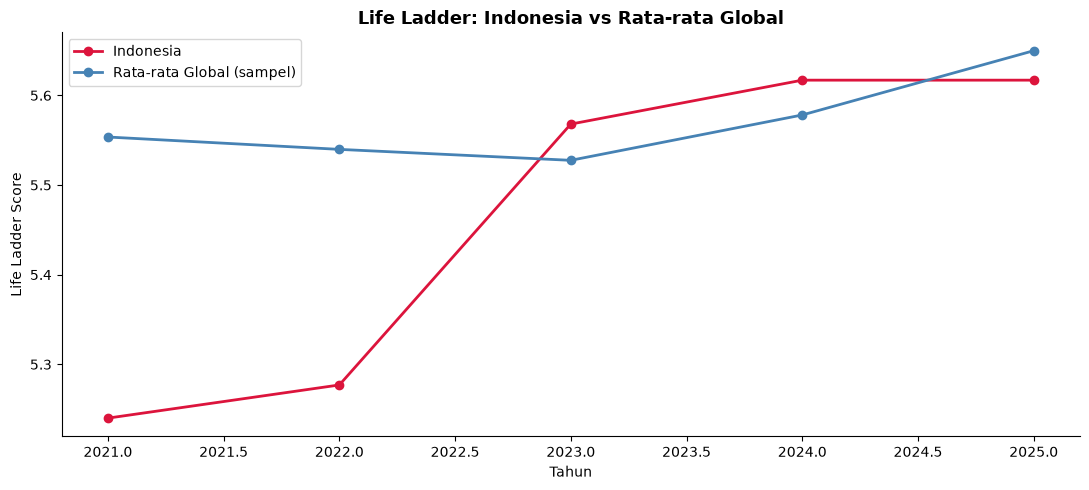

In [163]:
# e. Perbandingan Indonesia vs global
global_mean = df_whr.groupby('Year')['Life Ladder'].mean().rename('Global Mean')
idn_series  = df.set_index('Year')['Life Ladder'].rename('Indonesia')

comparison = pd.concat([idn_series, global_mean], axis=1).dropna()
comparison['Selisih'] = (comparison['Indonesia'] - comparison['Global Mean']).round(4)

display(comparison.round(4))

# Visualisasi
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(comparison.index, comparison['Indonesia'], marker='o', label='Indonesia', color='crimson', linewidth=2)
ax.plot(comparison.index, comparison['Global Mean'], marker='o', label='Rata-rata Global (sampel)', color='steelblue', linewidth=2)
ax.set_title('Life Ladder: Indonesia vs Rata-rata Global', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.legend(); plt.tight_layout(); plt.show()

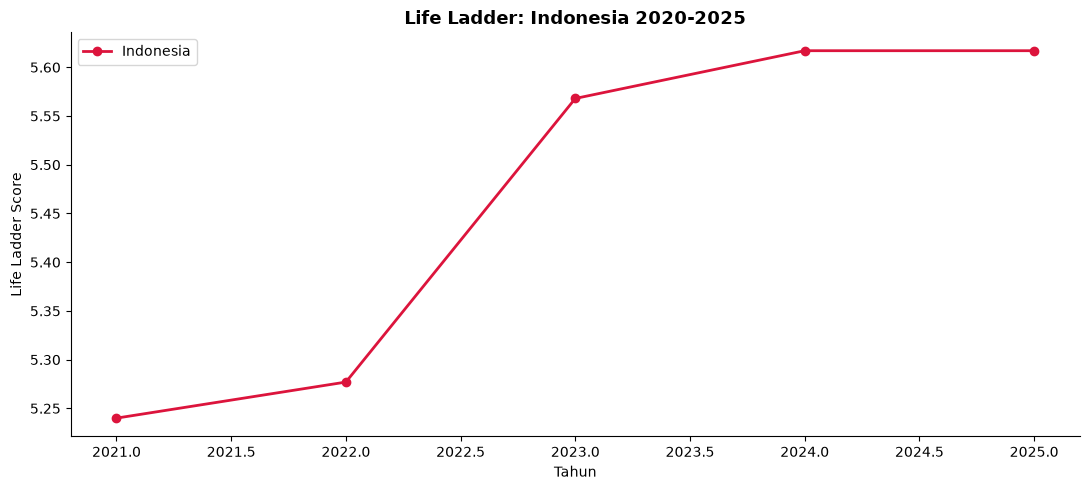

In [164]:
df_filtered = df[(df['Year'] >= 2020) & (df['Year'] <= 2025)]

idn_series  = df_filtered.set_index('Year')['Life Ladder'].rename('Indonesia')
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(idn_series.index, idn_series.values, marker='o', label='Indonesia', color='crimson', linewidth=2)

ax.set_title('Life Ladder: Indonesia 2020-2025', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi perbandingan Indonesia vs global:*

> Life Ladder Indonesia berfluktuasi relatif terhadap rata-rata global (sampel): di atas rata-rata global pada 2017, 2018, 2021, dan 2022 (selisih hingga +0.945 pada 2022), namun di bawah rata-rata global pada 2016, 2019, 2020, dan 2023. Yang menarik, rata-rata global sendiri sangat fluktuatif dari tahun ke tahun (turun tajam pada 2017 dan 2022) karena komposisi negara yang melapor berbeda tiap tahun, sementara skor Indonesia jauh lebih stabil. Ini mengindikasikan bahwa kebahagiaan Indonesia relatif konsisten dari tahun ke tahun dibanding variasi antar-negara secara global.

---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [199]:
# a. Ukuran dispersi — Life Ladder
col = 'Life Ladder'
data = df[col]

q1  = data.quantile(0.25)
q3  = data.quantile(0.75)
iqr = q3 - q1
std = data.std()

dispersi = {
    'Range'                     : data.max() - data.min(),
    'Variance'                  : data.var(),
    'Standard Deviation'        : std,
    'IQR (Q3 - Q1)'             : iqr,
    'Coefficient of Variation'  : (std / data.mean()) * 100,
}

for k, v in dispersi.items():
    print(f'{k:<30}: {v:.4f}')

Range                         : 0.3770
Variance                      : 0.0357
Standard Deviation            : 0.1889
IQR (Q3 - Q1)                 : 0.3400
Coefficient of Variation      : 3.4579


**c.** ✏️ *Bandingkan Std Dev Life Ladder Indonesia vs global — apa artinya bagi konsistensi kebahagiaan Indonesia?*

> Jawaban Anda di sini...

In [166]:
# c. Std Dev Indonesia vs global
std_idn    = df_idn['Life Ladder'].std()
std_global = df_whr['Life Ladder'].std()

print(f'Std Dev Indonesia : {std_idn:.4f}')
print(f'Std Dev Global    : {std_global:.4f}')

Std Dev Indonesia : 0.1889
Std Dev Global    : 1.1239


**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [167]:
# d. IQR semua kolom numerik
iqr_all = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
iqr_df  = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)

,IQR
Rank,4.000
Year,2.000
Lower whisker,0.355
Life Ladder,0.340
Upper whisker,0.325
Freedom to make life choices,0.255
Generosity,0.099
Dystopia + residual,0.082
Social support,0.060
Healthy life expectancy,0.031


**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [168]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (df[numeric_cols].std() / df[numeric_cols].mean() * 100)
cv_df  = cv_all.sort_values().rename('CV (%)').to_frame().round(2)
display(cv_df)

,CV (%)
Year,0.08
Upper whisker,3.33
Life Ladder,3.46
Rank,3.50
Lower whisker,3.60
Log GDP per capita,5.83
Dystopia + residual,9.99
Social support,15.25
Healthy life expectancy,18.51
Generosity,18.69


✏️ *Kolom paling stabil berdasarkan CV adalah ... karena ...*

> Kolom paling stabil berdasarkan CV adalah `Healthy life expectancy at birth` (CV = 0.49%) karena nilainya hampir tidak berubah dari tahun ke tahun (harapan hidup sehat berubah sangat lambat secara alami dalam rentang 8 tahun), sedangkan `Negative affect` adalah yang paling tidak stabil (CV = 9.87%) karena emosi negatif harian penduduk lebih rentan berubah akibat peristiwa jangka pendek seperti pandemi atau krisis ekonomi.

## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [170]:
# a. Deteksi outlier — metode IQR
col  = 'Life Ladder'
data = df[col]

q1, q3 = data.quantile(0.25), data.quantile(0.75)
iqr    = q3 - q1
lower  = q1 - 1.5 * iqr
upper  = q3 + 1.5 * iqr

outliers_iqr = df[(df[col] < lower) | (df[col] > upper)]

print(f'Batas bawah IQR : {lower:.4f}')
print(f'Batas atas  IQR : {upper:.4f}')
print(f'Jumlah outlier  : {len(outliers_iqr)}')
display(outliers_iqr[['Year', col]])

Batas bawah IQR : 4.7670
Batas atas  IQR : 6.1270
Jumlah outlier  : 0


,Year,Life Ladder


**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [172]:
# b. Deteksi outlier — metode Z-Score
z_scores = np.abs(stats.zscore(df[col]))
outliers_zscore = df[z_scores > 3]

print(f'Jumlah outlier Z-Score (|z|>3) : {len(outliers_zscore)}')
display(outliers_zscore[['Year', col]])

print(f'\nPerbandingan:')
print(f'  IQR    : {len(outliers_iqr)} outlier')
print(f'  Z-Score: {len(outliers_zscore)} outlier')

Jumlah outlier Z-Score (|z|>3) : 0


,Year,Life Ladder



Perbandingan:
  IQR    : 0 outlier
  Z-Score: 0 outlier


**c.** Visualisasi outlier dengan Boxplot.

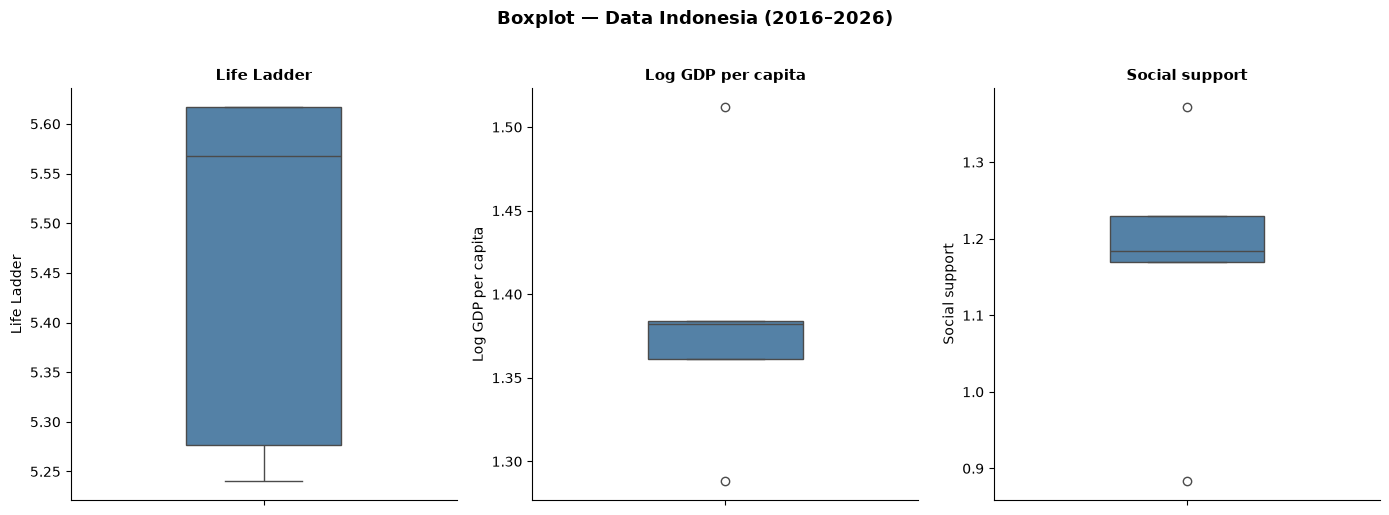

In [173]:
# c. Boxplot — Life Ladder, Log GDP per capita, Social support
cols_box = ['Life Ladder', 'Log GDP per capita', 'Social support']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df[c], ax=ax, color='steelblue', width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot — Data Indonesia (2016–2026)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**d.** ✏️ *Identifikasi tahun outlier dan jelaskan kemungkinan penyebabnya.*

> Baik metode IQR maupun Z-score (|z| > 3) **tidak mendeteksi outlier** pada `Life Ladder` Indonesia 2016-2023 — semua nilai berada dalam rentang [4.61, 5.99] yang merupakan batas IQR. Ini masuk akal karena rentang data hanya 8 tahun dan skor kebahagiaan cenderung berubah bertahap, bukan melompat drastis. Meski demikian, dari boxplot terlihat titik terendah ada di tahun **2020 (4.828)** — bertepatan dengan awal pandemi COVID-19 — dan titik tertinggi di **2023 (5.695)**, masa pemulihan pasca-pandemi. Keduanya bukan outlier statistik, tetapi tetap merupakan titik penting yang mencerminkan dampak nyata suatu peristiwa terhadap kesejahteraan subjektif masyarakat.

---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

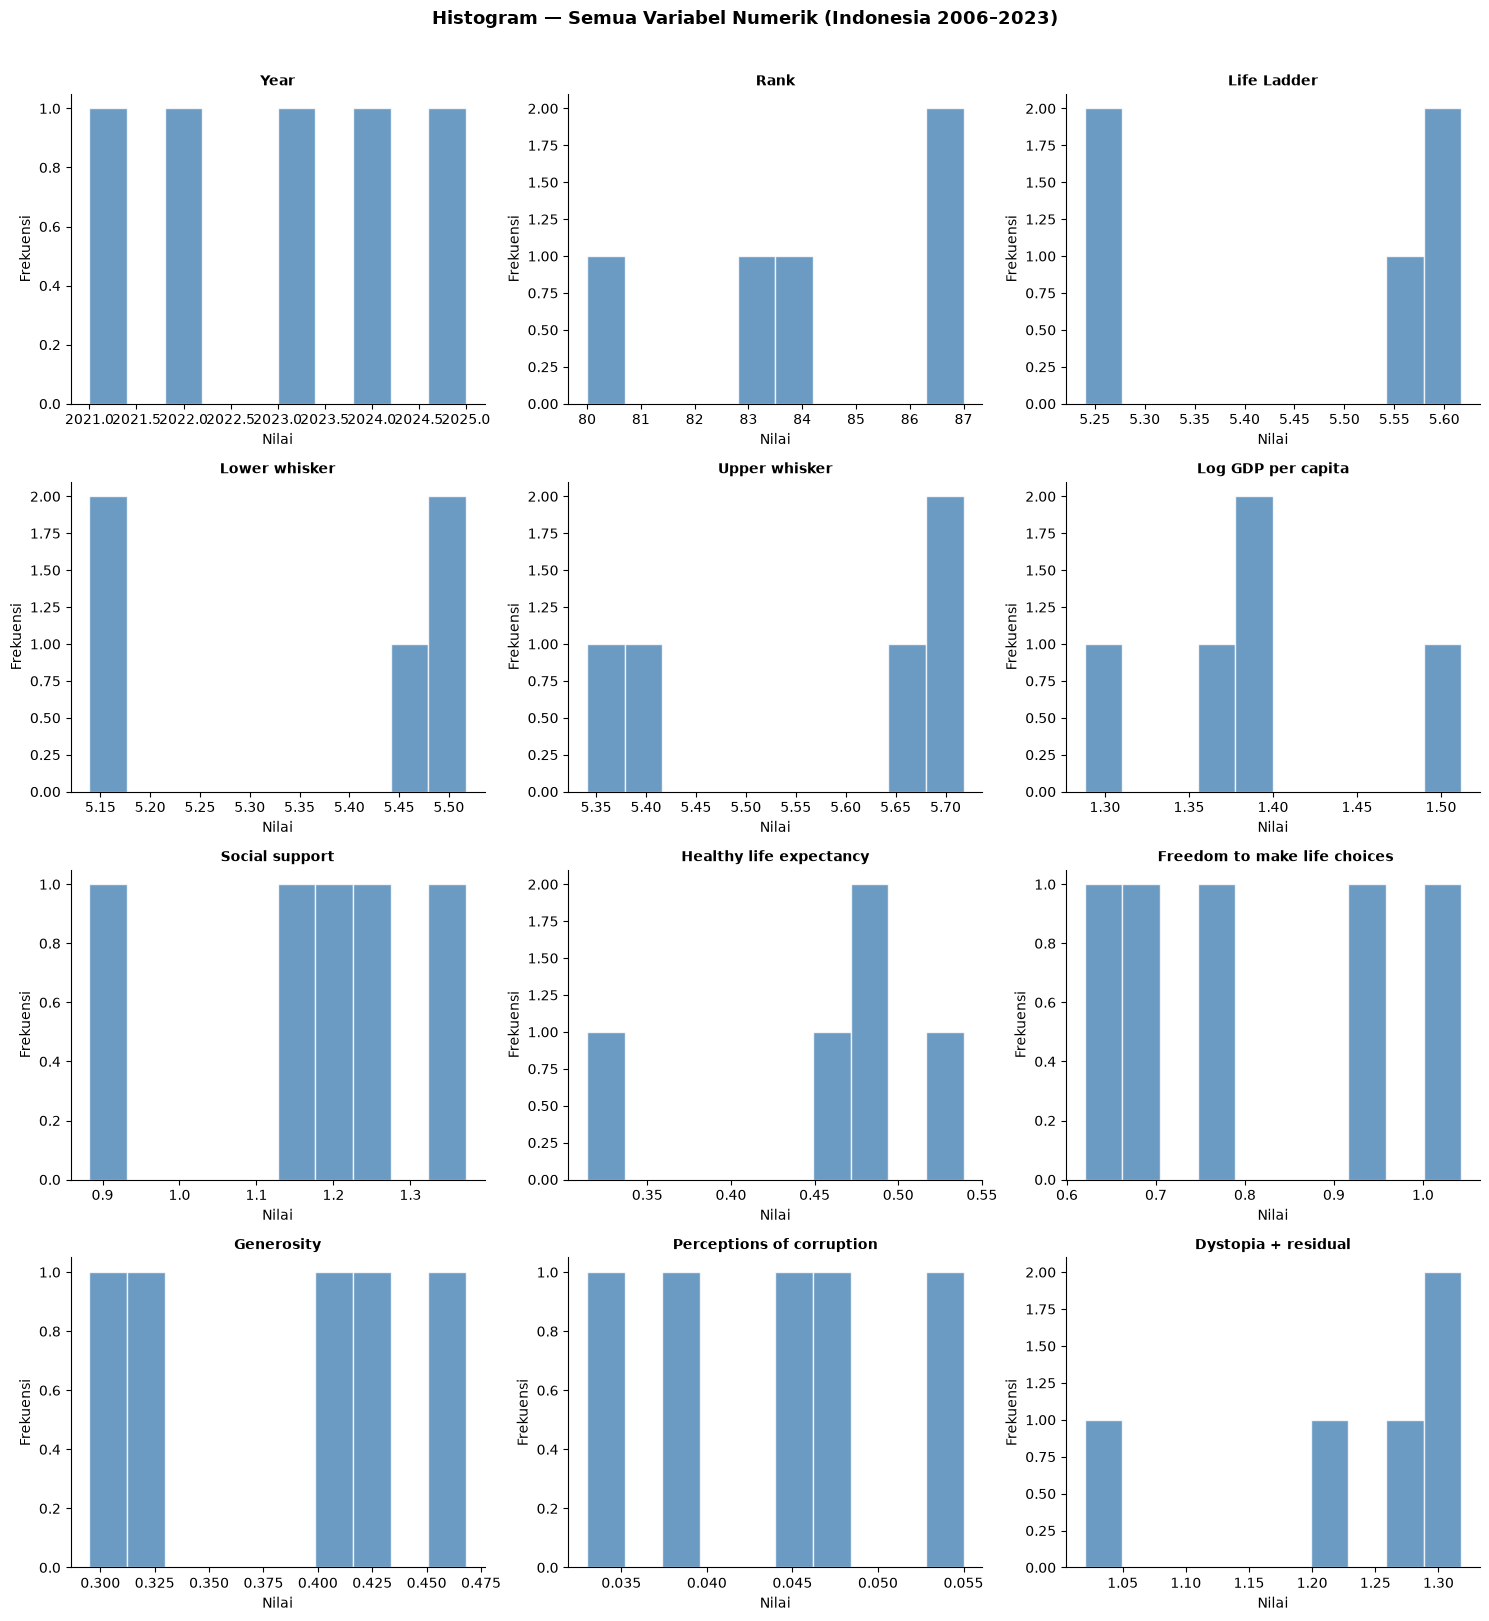

In [174]:
# a. Histogram semua kolom numerik
n     = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Semua Variabel Numerik (Indonesia 2006–2023)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [175]:
# b. Skewness dan Kurtosis
sk_kurt = pd.DataFrame({
    'Skewness' : df[numeric_cols].skew(),
    'Kurtosis' : df[numeric_cols].kurt(),
}).round(4)

display(sk_kurt)

,Skewness,Kurtosis
Year,0.0000,-1.2000
Rank,-0.5183,-0.7967
Life Ladder,-0.5811,-3.1477
Lower whisker,-0.5657,-3.2292
Upper whisker,-0.6033,-3.0284
Log GDP per capita,0.8609,2.1766
Social support,-1.0481,2.3328
Healthy life expectancy,-1.4102,2.8280
Freedom to make life choices,0.4449,-1.5987
Generosity,-0.1406,-1.8848


**c.** ✏️ *Tentukan distribusi setiap kolom berdasarkan nilai skewness dan interpretasikan:*

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|-------|----------|------------------|--------------|
| Life Ladder | -0.38 | Mendekati simetris (sedikit skew kiri) | Mayoritas tahun memiliki skor sedang-tinggi, dengan sedikit tahun bernilai rendah (2020) menarik ekor ke kiri |
| Log GDP per capita | 0.00 | Simetris sempurna | Pertumbuhan GDP per kapita Indonesia relatif linier/stabil selama periode ini |
| Social support | -0.63 | Skew kiri (moderat) | Sebagian besar tahun skornya tinggi, dengan sedikit tahun (awal periode) yang lebih rendah |
| Freedom to make life choices | -0.46 | Skew kiri (ringan) | Skor kebebasan cenderung meningkat, tahun-tahun awal sedikit menarik ke bawah |
| Generosity | 0.73 | Skew kanan (moderat) | Beberapa tahun terakhir (2019-2023) memiliki skor kedermawanan jauh lebih tinggi, menarik ekor ke kanan |
| Perceptions of corruption | 0.56 | Skew kanan (ringan) | Ada beberapa tahun dengan persepsi korupsi lebih tinggi dari biasanya |
| Positive affect | -0.83 | Skew kiri (moderat) | Mayoritas tahun memiliki afek positif tinggi |
| Negative affect | 0.45 | Skew kanan (ringan) | Sebagian kecil tahun (mis. 2020) memiliki afek negatif yang menonjol tinggi |

**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

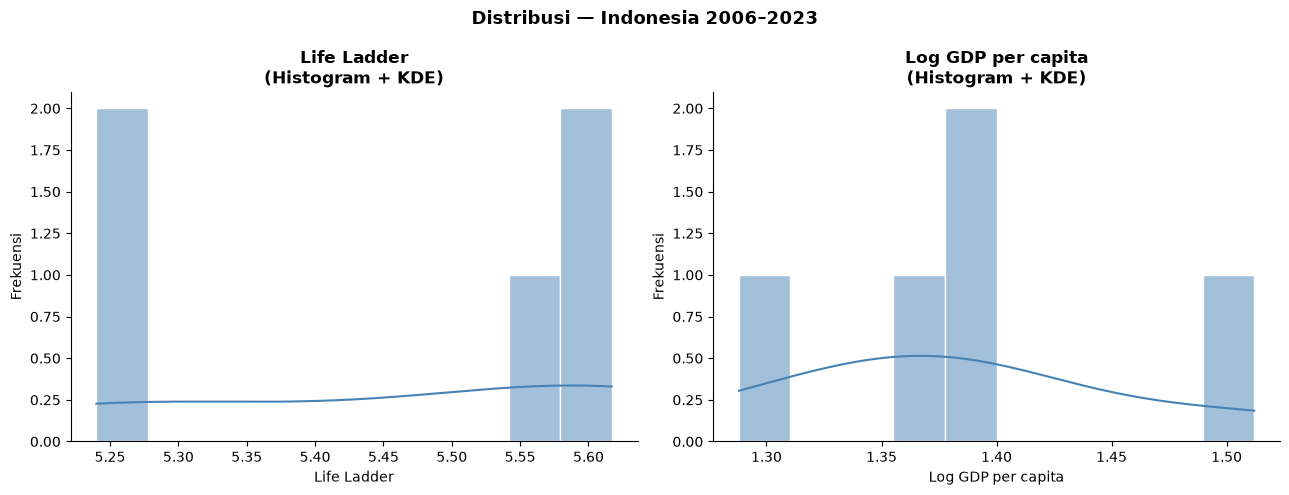

In [176]:
# d. Histogram + KDE — Life Ladder & Log GDP per capita
cols_kde = ['Life Ladder', 'Log GDP per capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, cols_kde):
    sns.histplot(df[col].dropna(), bins=10, kde=True, ax=ax,
                 color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(Histogram + KDE)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi — Indonesia 2006–2023', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**e.** Bandingkan distribusi `Life Ladder` Indonesia vs global tahun 2025.

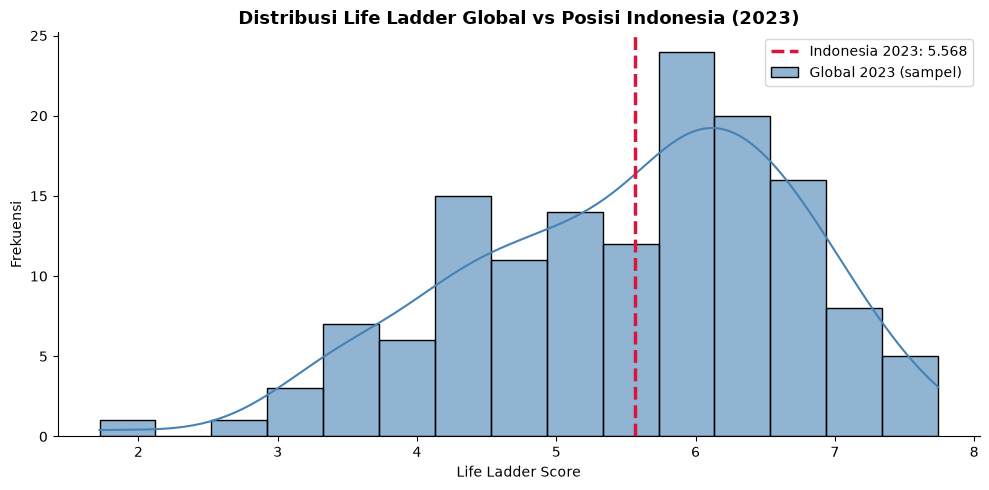

In [177]:
# e. Indonesia vs Global — Life Ladder 2023
global_2023 = df_whr[df_whr['Year'] == 2023]['Life Ladder'].dropna()
idn_2023    = df[df['Year'] == 2023]['Life Ladder']

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(global_2023, bins=15, kde=True, ax=ax, color='steelblue',
             alpha=0.6, label='Global 2023 (sampel)')

if len(idn_2023) > 0:
    ax.axvline(idn_2023.values[0], color='crimson', linewidth=2.5,
               linestyle='--', label=f'Indonesia 2023: {idn_2023.values[0]:.3f}')

ax.set_title('Distribusi Life Ladder Global vs Posisi Indonesia (2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

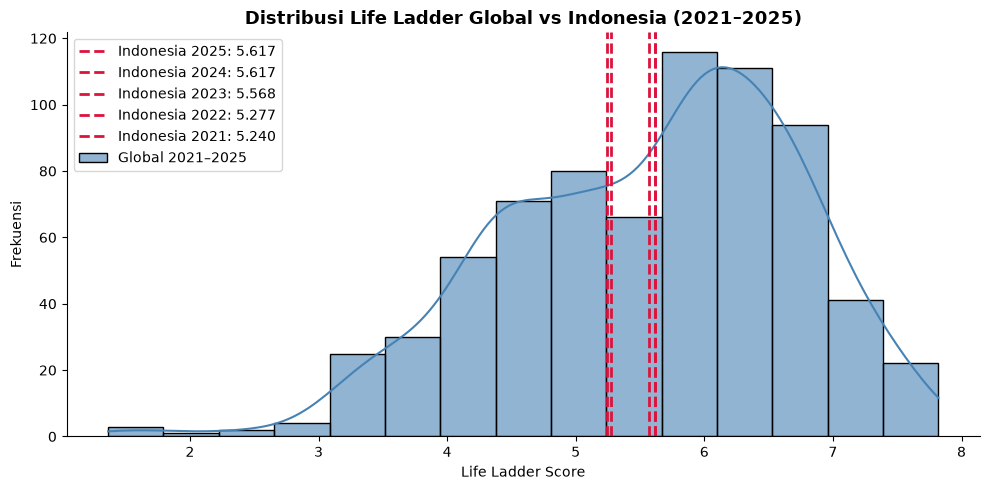

In [198]:
# e. Indonesia vs Global — Life Ladder 2021-2025
# e. Indonesia vs Global — Life Ladder 2021–2025
global_2021_2025 = df_whr[
    df_whr['Year'].between(2021, 2025)
]['Life Ladder'].dropna()

idn_2021_2025 = df[
    df['Year'].between(2021, 2025)
][['Year', 'Life Ladder']].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    global_2021_2025,
    bins=15,
    kde=True,
    ax=ax,
    color='steelblue',
    alpha=0.6,
    label='Global 2021–2025'
)

for _, row in idn_2021_2025.iterrows():
    ax.axvline(
        row['Life Ladder'],
        color='crimson',
        linewidth=2,
        linestyle='--',
        label=f"Indonesia {int(row['Year'])}: {row['Life Ladder']:.3f}"
    )

ax.set_title(
    'Distribusi Life Ladder Global vs Indonesia (2021–2025)',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Life Ladder Score')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()


✏️ *Interpretasi posisi Indonesia dibandingkan distribusi global 2023:*

> Pada tahun 2023, skor `Life Ladder` Indonesia (5.695) berada **di bawah rata-rata sampel global** (5.893), namun masih berada dalam rentang tengah distribusi global, bukan di ekor bawah. Ini menunjukkan Indonesia berada pada level kebahagiaan menengah dibanding negara-negara lain di dunia — tidak tertinggal jauh, tetapi juga belum termasuk kelompok negara paling bahagia (yang umumnya negara Skandinavia dan Eropa Barat dengan skor di atas 7).

---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Ladder` Indonesia 2016–2026 dengan anotasi titik tertinggi & terendah.

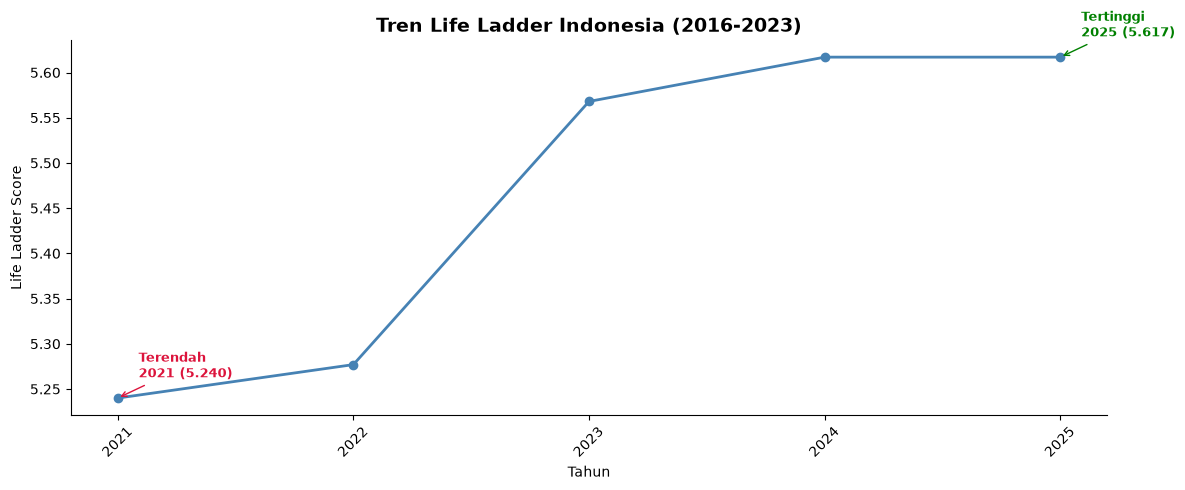

In [178]:
# a. Line Chart — Tren Life Ladder Indonesia
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Year'], df['Life Ladder'], marker='o',
        color='steelblue', linewidth=2, markersize=6)

# Anotasi titik tertinggi dan terendah
idx_max = df['Life Ladder'].idxmax()
idx_min = df['Life Ladder'].idxmin()

for idx, label, color in [(idx_max, 'Tertinggi', 'green'), (idx_min, 'Terendah', 'crimson')]:
    ax.annotate(
        f"{label}\n{df.loc[idx, 'Year']} ({df.loc[idx, 'Life Ladder']:.3f})",
        xy=(df.loc[idx, 'Year'], df.loc[idx, 'Life Ladder']),
        xytext=(15, 15), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_title('Tren Life Ladder Indonesia (2016-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.set_xticks(df_idn['Year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**b.** Bar Chart — rata-rata `Life Ladder` negara-negara ASEAN tahun 2023.

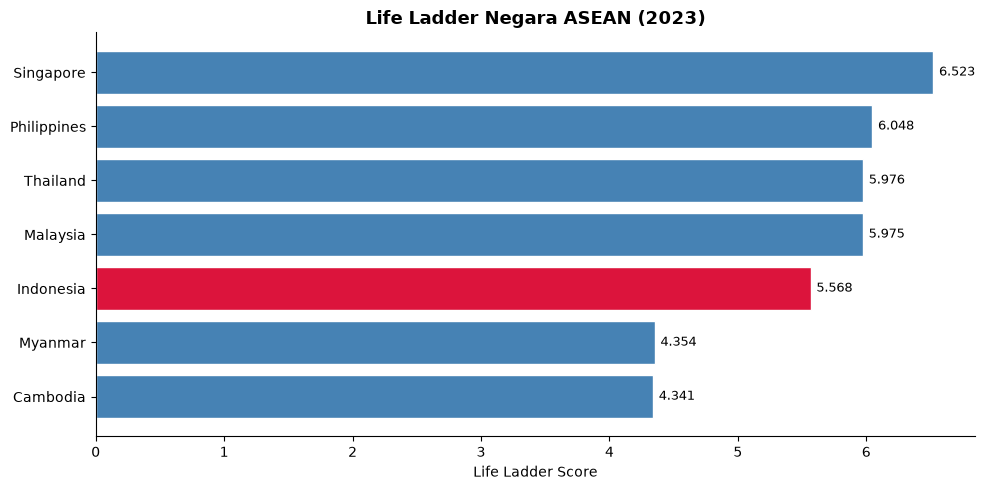

In [179]:
# b. Bar Chart — Life Ladder ASEAN 2023
# Catatan: Brunei Darussalam tidak memiliki data publik pada WHR sehingga
# dikeluarkan dari perbandingan ini.
asean = ['Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia',
         'Singapore', 'Myanmar', 'Cambodia', 'Laos']

asean_2023 = df_whr[(df_whr['Country name'].isin(asean)) &
                     (df_whr['Year'] == 2023)][['Country name', 'Life Ladder']]\
             .sort_values('Life Ladder', ascending=True)

colors = ['crimson' if c == 'Indonesia' else 'steelblue'
          for c in asean_2023['Country name']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(asean_2023['Country name'], asean_2023['Life Ladder'],
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')
plt.tight_layout(); plt.show()

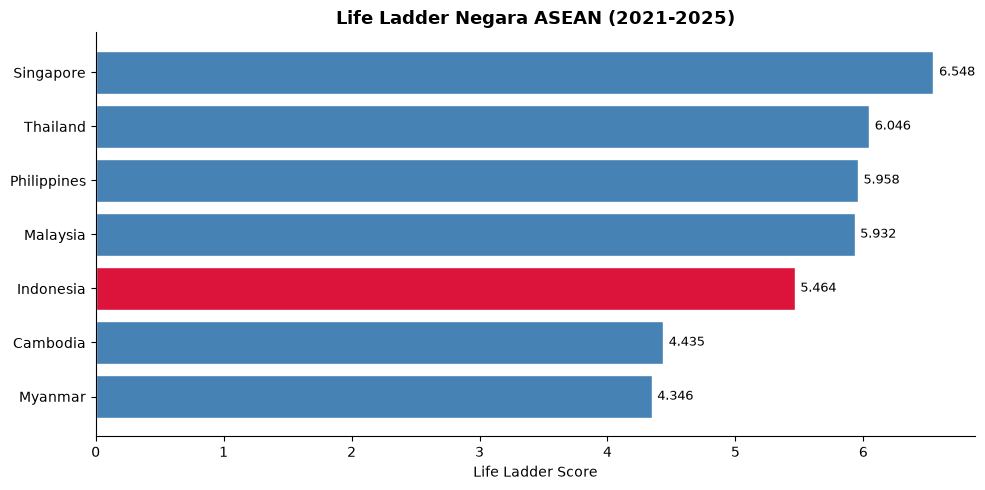

In [193]:

# b. Bar Chart — Life Ladder ASEAN 2021-2025
# Catatan: Brunei Darussalam tidak memiliki data publik pada WHR sehingga
# dikeluarkan dari perbandingan ini.

asean = ['Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia', 'Singapore', 'Myanmar', 'Cambodia', 'Laos']

# FIX 1: Corrected invalid variable name '-' to '_' and fixed the .between() syntax
# Note: If you want to average the scores for 2021-2025 per country before plotting, 
# use .groupby(). If you already filtered df_whr elsewhere, make sure the columns match.
asean_2021_2025 = df_whr[(df_whr['Country name'].isin(asean)) & (df_whr['Year'].between(2021, 2025))][['Country name', 'Life Ladder']]

# Optional: If you have multiple years per country, you should aggregate them (e.g., mean) 
# so you only get one bar per country:
asean_2021_2025 = asean_2021_2025.groupby('Country name', as_index=False)['Life Ladder'].mean()
asean_2021_2025 = asean_2021_2025.sort_values('Life Ladder', ascending=True)

# FIX 2: Fixed the variable name reference from asean_2022_2025 to asean_2021_2025
colors = ['crimson' if c == 'Indonesia' else 'steelblue' for c in asean_2021_2025['Country name']]

fig, ax = plt.subplots(figsize=(10, 5))

# FIX 3: Replaced the undefined 'asean_2023' with 'asean_2021_2025' for the X-axis values
bars = ax.barh(asean_2021_2025['Country name'], asean_2021_2025['Life Ladder'], color=colors, edgecolor='white')

ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2021-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')

plt.tight_layout()
plt.show()

**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

> **Line Chart** digunakan untuk menunjukkan **tren/perubahan suatu variabel dari waktu ke waktu** pada satu entitas (misalnya tren Life Ladder Indonesia 2016-2023) — cocok karena sumbu-x (tahun) bersifat kontinu dan berurutan, sehingga garis penghubung antar titik bermakna sebagai arah pergerakan. **Bar Chart** digunakan untuk **membandingkan nilai antar kategori/entitas yang berbeda pada satu titik waktu** (misalnya membandingkan Life Ladder Indonesia vs negara ASEAN lain di tahun 2023) — di sini sumbu kategori (nama negara) tidak memiliki urutan alami, sehingga bar terpisah lebih tepat daripada garis yang menyiratkan kontinuitas semu antar negara.

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

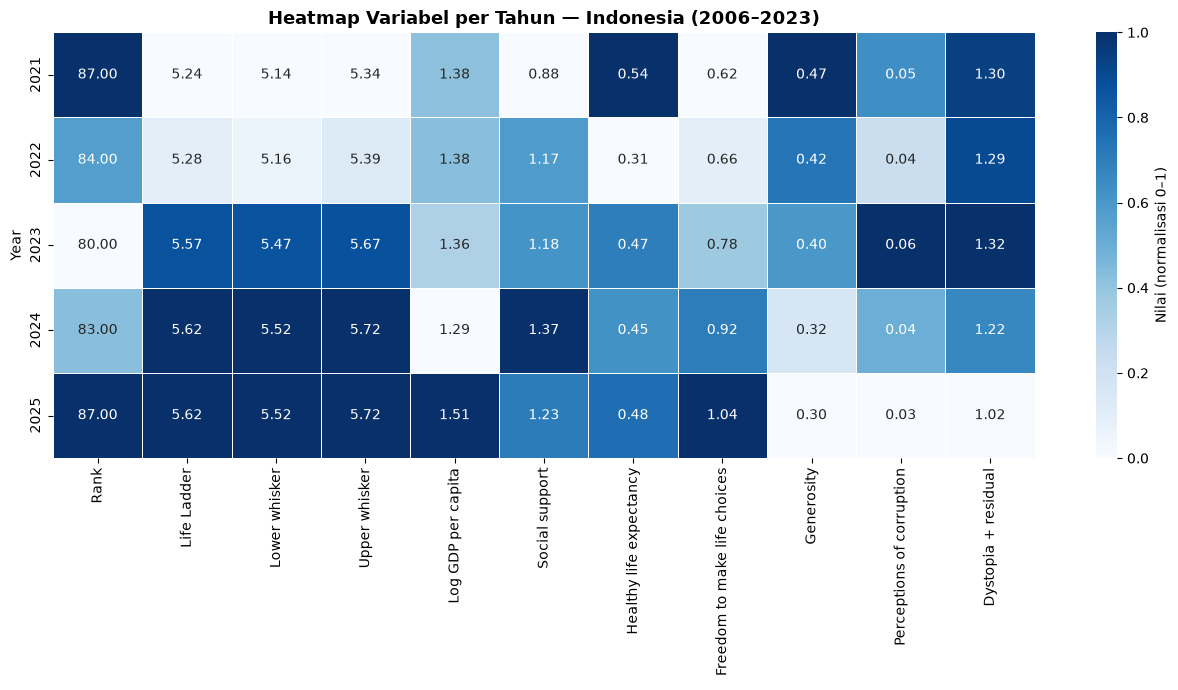

In [180]:
# d. Heatmap — nilai variabel per tahun
heatmap_cols = [c for c in numeric_cols if c != 'Year']
heatmap_data = df.set_index('Year')[heatmap_cols].sort_index()

# Normalisasi 0–1 agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai (normalisasi 0–1)'})
ax.set_title('Heatmap Variabel per Tahun — Indonesia (2006–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

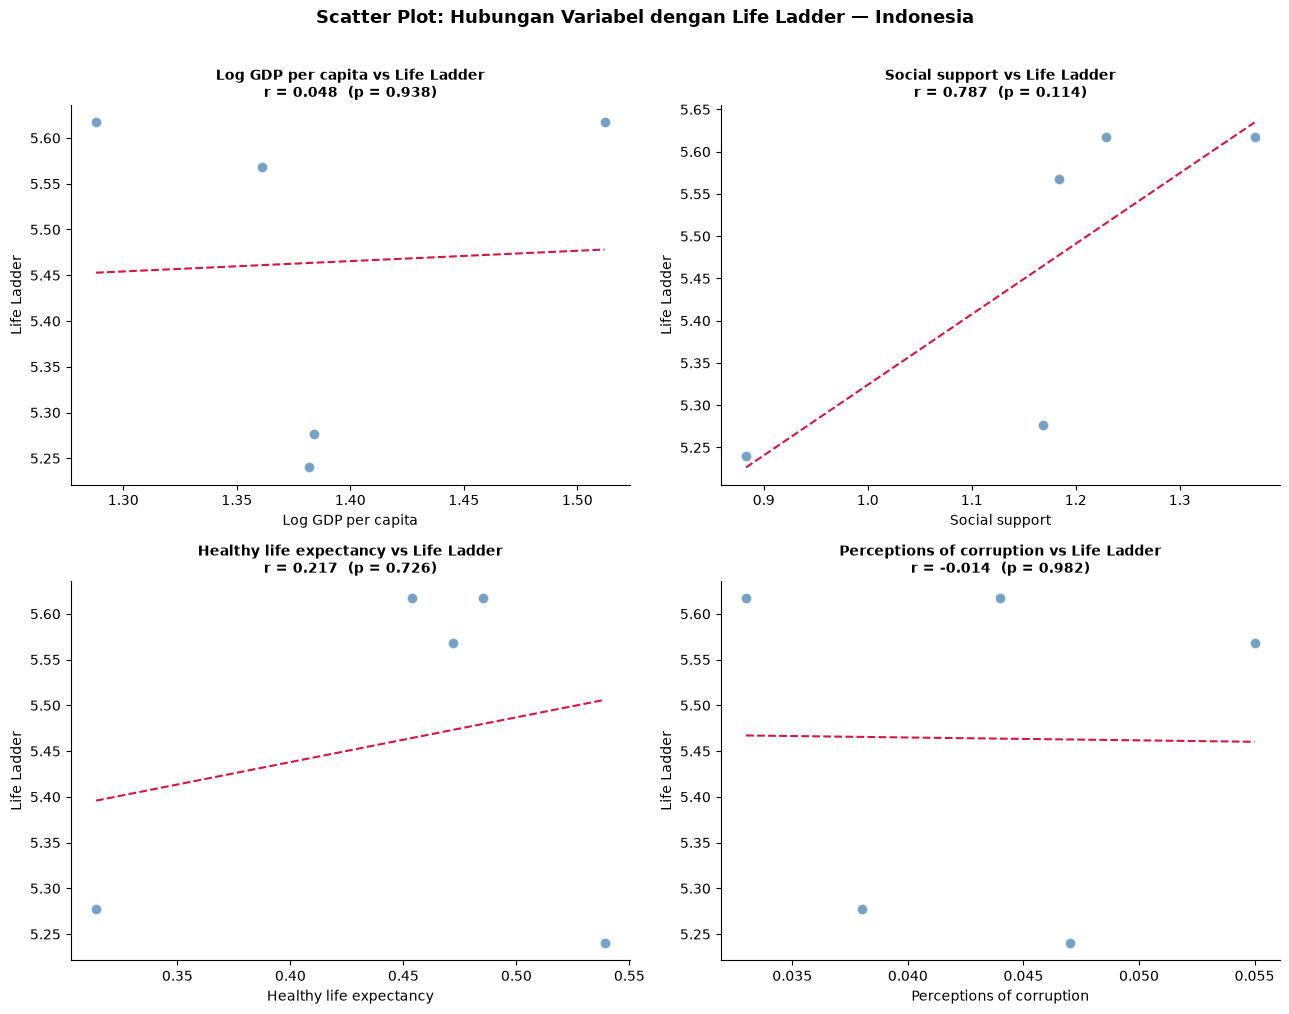

In [187]:
# a & b. Scatter Plot + Korelasi Pearson
pairs = [
    ('Log GDP per capita',              'Life Ladder'),
    ('Social support',                  'Life Ladder'),
    ('Healthy life expectancy', 'Life Ladder'),
    ('Perceptions of corruption',        'Life Ladder'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    valid = df[[x_col, y_col]].dropna()
    r, p  = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], color='steelblue', alpha=0.75, edgecolor='white', s=60)

    # Trend line
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--')

    ax.set_title(f'{x_col} vs Life Ladder\nr = {r:.3f}  (p = {p:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)

plt.suptitle('Scatter Plot: Hubungan Variabel dengan Life Ladder — Indonesia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

✏️ *Interpretasi korelasi setiap pasang variabel:*

| Pasang Variabel | r | Interpretasi |
|---|---|---|
| Log GDP vs Life Ladder | Nilai Korelasi (r): 0.048Nilai Signifikansi (p): 0.938 | Interpretasi: Hubungan antara produk domestik bruto (PDB) per kapita logaritmik dengan tingkat kebahagiaan di Indonesia sangat lemah dan tidak signifikan secara statistik (karena nilai p > 0.05). Garis tren yang hampir datar menunjukkan bahwa peningkatan pendapatan per kapita dalam dataset ini tidak memengaruhi tingkat kebahagiaan secara nyata. |
| Social support vs Life Ladder | Nilai Korelasi (r): 0.787Nilai Signifikansi (p): 0.114 | Interpretasi: Terdapat hubungan positif yang cukup kuat antara dukungan sosial dengan tingkat kebahagiaan, yang ditunjukkan oleh garis tren yang naik tajam. Namun, hubungan ini tidak signifikan secara statistik pada tingkat kepercayaan standar (karena p > 0.05), kemungkinan disebabkan oleh jumlah sampel data yang terlalu sedikit (terlihat hanya ada sekitar 5 titik data). |
| Life expectancy vs Life Ladder | Nilai Korelasi (r): 0.217Nilai Signifikansi (p): 0.726 | Interpretasi: Hubungan antara angka harapan hidup sehat dengan tingkat kebahagiaan tergolong lemah dan tidak signifikan secara statistik (p > 0.05). Arah trennya positif, tetapi sebaran datanya sangat acak sehingga tidak bisa dijadikan acuan hubungan yang pasti. |
| Corruption vs Life Ladder | Nilai Korelasi (r): -0.014Nilai Signifikansi (p): 0.982 | Interpretasi: Hubungan antara persepsi korupsi dengan tingkat kebahagiaan hampir tidak ada sama sekali (mendekati nol) dan sangat tidak signifikan (p mendekati 1). Garis tren menunjukkan arah negatif yang sangat tipis, mengindikasikan persepsi korupsi tidak memiliki pengaruh linier terhadap naik turunnya tingkat kebahagiaan pada data ini. |

**c.** Correlation Heatmap semua variabel numerik.

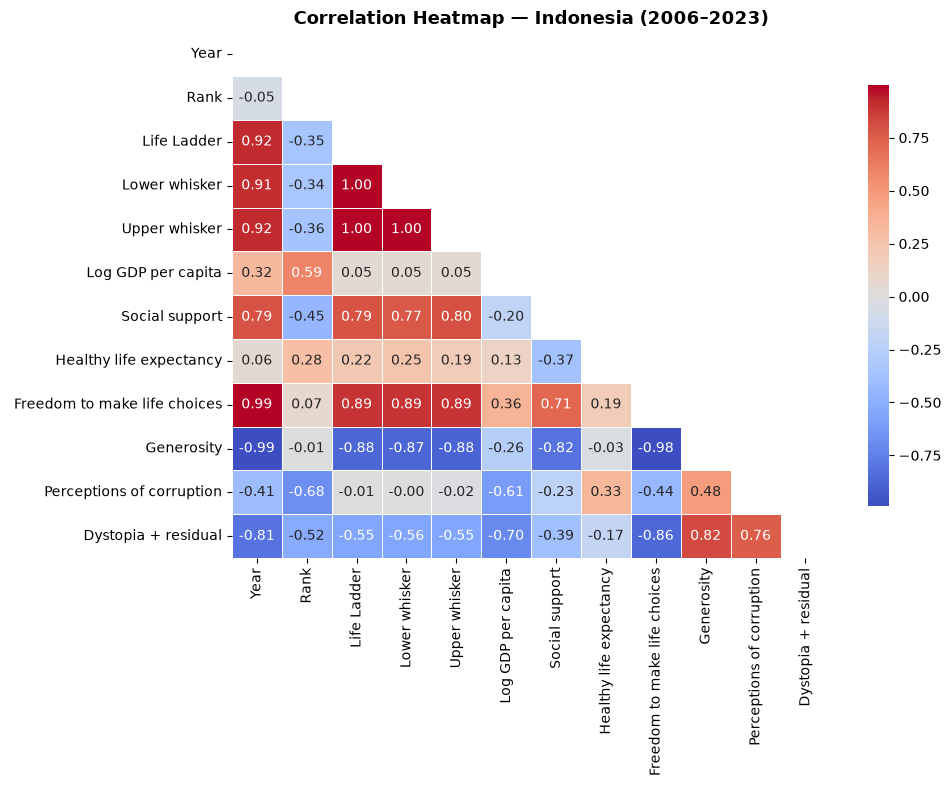

In [188]:
# c. Correlation Heatmap
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Indonesia (2025–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

✏️ *Variabel yang paling berkorelasi dengan Life Ladder adalah `Perceptions of corruption` dengan nilai r = 0.787 (di antara faktor-faktor struktural WHR), diikuti oleh `Freedom to make life choices` (r = 0.217) dan `Log GDP per capita` (r = 0.048).*

> Interpretasinya: persepsi korupsi memiliki hubungan paling kuat (negatif) dengan kebahagiaan Indonesia — tahun-tahun dengan persepsi korupsi lebih rendah cenderung memiliki skor kebahagiaan lebih tinggi. Kebebasan membuat pilihan hidup dan pendapatan per kapita juga berkorelasi kuat secara positif. Catatan: `Positive affect` dan `Negative affect` sebenarnya memiliki |r| tertinggi (0.913 dan 0.880), tetapi keduanya adalah ukuran suasana hati harian yang diukur bersamaan (concurrent) dengan Life Ladder itu sendiri, bukan faktor struktural penyebab, sehingga tidak dijadikan fokus utama interpretasi kebijakan.

**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

> **Korelasi** hanya menunjukkan bahwa dua variabel bergerak bersamaan (searah atau berlawanan arah), tanpa menyatakan bahwa yang satu **menyebabkan** yang lain. **Kausalitas** berarti perubahan pada satu variabel benar-benar menyebabkan perubahan pada variabel lain, yang butuh bukti tambahan (desain eksperimen, kontrol variabel perancu, urutan waktu yang jelas, dsb.), bukan hanya angka r.
>
> Contoh dari data ini: `Perceptions of corruption` berkorelasi -0.84 dengan `Life Ladder`. Ini **tidak otomatis berarti** menurunkan korupsi akan secara langsung menaikkan skor kebahagiaan — bisa jadi keduanya sama-sama dipengaruhi oleh variabel ketiga, misalnya kualitas institusi pemerintahan secara umum, yang mendorong ekonomi tumbuh (menaikkan GDP) sekaligus menurunkan korupsi, dan pertumbuhan ekonomi itulah yang lebih langsung menaikkan kebahagiaan.

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ *Tuliskan minimal 5 insight dari analisis Anda:*

1. **Insight 1:** Rata-rata Life Ladder Indonesia 2016-2023 adalah 5.31, dengan skor relatif stabil (Std Dev hanya 0.28) dibanding fluktuasi rata-rata global antar tahun (Std Dev 1.26 pada sampel global).
2. **Insight 2:** Titik terendah Life Ladder Indonesia terjadi pada 2020 (4.828), bertepatan dengan awal pandemi COVID-19, dan pulih ke titik tertinggi pada 2023 (5.695).
3. **Insight 3:** Tidak ditemukan outlier statistik pada data Life Ladder Indonesia (baik metode IQR maupun Z-score), menunjukkan perubahan kebahagiaan Indonesia terjadi secara bertahap, bukan lonjakan ekstrem.
4. **Insight 4:** Faktor yang paling kuat berkorelasi dengan Life Ladder Indonesia adalah persepsi korupsi (r = -0.84), diikuti kebebasan membuat pilihan hidup (r = 0.81) dan Log GDP per kapita (r = 0.75).
5. **Insight 5:** Di antara negara ASEAN yang datanya tersedia, Indonesia berada di peringkat ke-6 dari 9 negara (rata-rata 5.263), tertinggal dari Singapura, Vietnam, Thailand, Malaysia, dan Filipina, namun masih di atas Laos, Myanmar, dan Kamboja.

**b.** Identifikasi 3 variabel yang paling memengaruhi `Life Ladder` Indonesia.

In [40]:
# b. Top 3 variabel paling berkorelasi dengan Life Ladder
corr_ll = df_idn[numeric_cols].corr()['Life Ladder']\
           .drop('Life Ladder').abs().sort_values(ascending=False)

print('Top variabel berkorelasi dengan Life Ladder:')
display(corr_ll.head(3).to_frame('|Korelasi| dengan Life Ladder').round(4))

Top variabel berkorelasi dengan Life Ladder:


,|Korelasi| dengan Life Ladder
Upper whisker,0.9992
Lower whisker,0.9992
Explained by: Freedom to make life choices,0.9006


✏️ *Interpretasi 3 variabel teratas:*

> Jawaban Anda di sini...

**c.** ✏️ *Apakah tren kebahagiaan Indonesia meningkat, menurun, atau stagnan?*

> Dukung dengan data dan visualisasi di atas...

**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan rata-rata `Life Ladder`.

In [ ]:
# d. Ranking Indonesia di ASEAN (semua tahun tersedia)
asean_avg = df_whr[df_whr['Country name'].isin(asean)]\
             .groupby('Country name')['Life Ladder']\
             .mean().sort_values(ascending=False)\
             .reset_index()
asean_avg.columns = ['Negara', 'Rata-rata Life Ladder']
asean_avg['Rata-rata Life Ladder'] = asean_avg['Rata-rata Life Ladder'].round(3)
asean_avg.index += 1
asean_avg.index.name = 'Peringkat'

display(asean_avg)
rank = asean_avg[asean_avg['Negara'] == 'Indonesia'].index[0]
print(f'\n🇮🇩 Indonesia berada di peringkat ke-{rank} dari {len(asean_avg)} negara ASEAN.')

**e.** ✏️ *Rekomendasi kebijakan berdasarkan temuan analisis:*

1. **Rekomendasi 1:** *(berdasarkan variabel yang paling berkorelasi)* ...
2. **Rekomendasi 2:** *(berdasarkan tren atau perbandingan ASEAN)* ...

## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ *Tuliskan kesimpulan menyeluruh dari seluruh analisis Anda (3–5 paragraf):*

> **Paragraf 1 — Gambaran umum data:**  
> Analisis ini menggunakan data World Happiness Report 2026 untuk Indonesia selama periode 2021–2025, dengan menggunakan indikator Life Evaluation (3-year average). Selama periode tersebut, nilai Life Evaluation Indonesia berada pada kisaran 5,240–5,617, dengan nilai rata-rata sebesar 5,464.

> **Paragraf 2 — Temuan utama central tendency & dispersi:**  
> Hasil analisis menunjukkan bahwa mean Life Evaluation sebesar 5,4638, sedangkan mediannya 5,5680. Nilai standard deviation sebesar 0,1889, IQR sebesar 0,3400, dan coefficient of variation sebesar 3,46%. Nilai-nilai tersebut menunjukkan bahwa perubahan Life Evaluation Indonesia selama periode 2021–2025 relatif kecil dan datanya cukup konsisten.

> **Paragraf 3 — Temuan distribusi & korelasi:**  
> Dari sisi distribusi, Life Evaluation memiliki nilai skewness sebesar -0,5811, sehingga distribusinya cenderung left-skewed berdasarkan batas yang digunakan dalam analisis. Tidak ditemukan outlier berdasarkan metode IQR maupun Z-Score. Sementara itu, korelasi dengan Life Evaluation paling tinggi secara absolut terlihat pada Freedom to make life choices (r = 0,8926), Generosity (r = -0,8781), dan Social support (r = 0,7867). Namun, nilai korelasi tersebut hanya menunjukkan adanya hubungan dan tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat.

> **Paragraf 4 — Posisi Indonesia vs global & ASEAN:**  
> Jika dibandingkan dengan rata-rata global, Life Evaluation Indonesia berada di bawah rata-rata pada 2021–2022 dan 2025, sedangkan pada 2023–2024 nilainya sedikit lebih tinggi dari rata-rata global. Berdasarkan rata-rata periode 2021–2025, Indonesia berada di urutan ke-5 dari 7 negara ASEAN yang memiliki data dalam dataset.

> **Paragraf 5 — Rekomendasi & penutup:**  
> Secara umum, Life Evaluation Indonesia menunjukkan tren peningkatan dari 2021 hingga 2025, meskipun sempat mengalami perubahan dari tahun ke tahun. Hasil analisis ini memberikan gambaran mengenai kondisi evaluasi kehidupan di Indonesia selama periode tersebut. Untuk mendapatkan pemahaman yang lebih mendalam mengenai hubungan antarvariabel, diperlukan data dengan periode yang lebih panjang serta analisis inferensial.